# `diffractio` Experimentation

See [tutorials](https://diffractio.readthedocs.io/en/latest/usage.html) on the docs page.

## X Fields

In [1]:
from diffractio import um, nm, mm, np
from diffractio.scalar_fields_X import Scalar_field_X
from diffractio.scalar_sources_X import Scalar_source_X
from diffractio.scalar_masks_X import Scalar_mask_X

Good result: factor 12.94


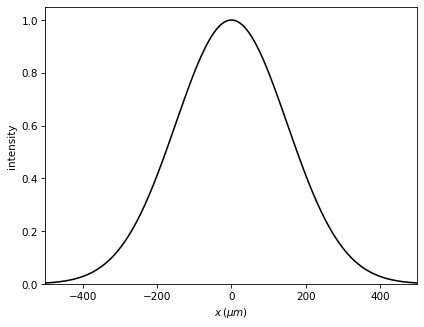

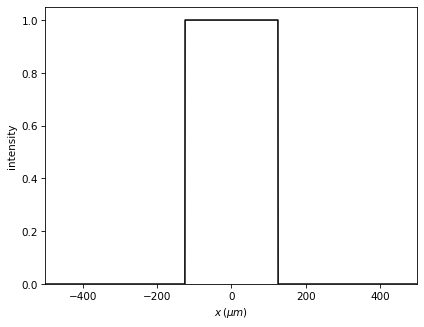

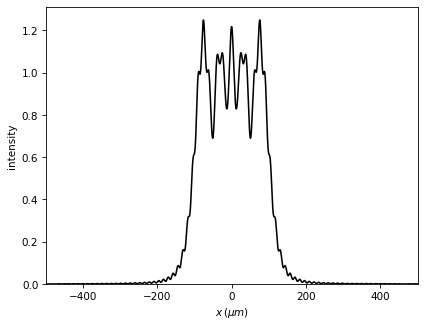

In [2]:
x = np.linspace(-500*um, 500*um, 4096)
wavelength = .6328*um

u0 = Scalar_source_X(x, wavelength)
u0.gauss_beam(x0=0, w0=300*um, z0=0)
u0.draw(filename='usage1.png')

t0=Scalar_mask_X(x, wavelength)
t0.slit(x0=0, size=250*um)
t0.draw(filename='usage2.png')

u1=t0*u0
u2 = u1.RS(z=5*mm, new_field=True)
u2.draw(filename='usage3.png')

## XZ Fields:

In [3]:
from diffractio import um, nm, mm, np,degrees
from diffractio.scalar_sources_X import Scalar_source_X
from diffractio.scalar_fields_XZ import Scalar_field_XZ
from diffractio.scalar_masks_XZ import Scalar_mask_XZ

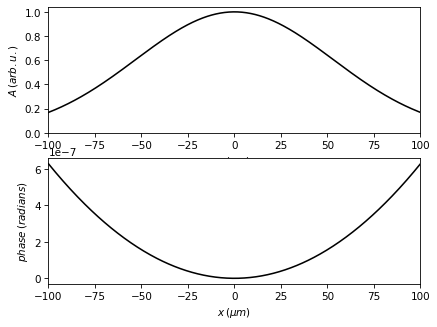

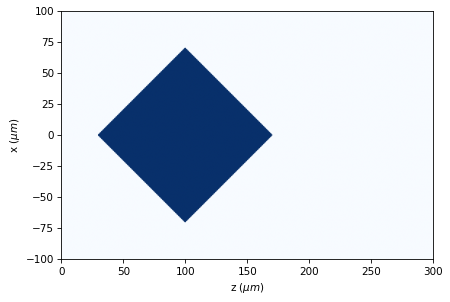

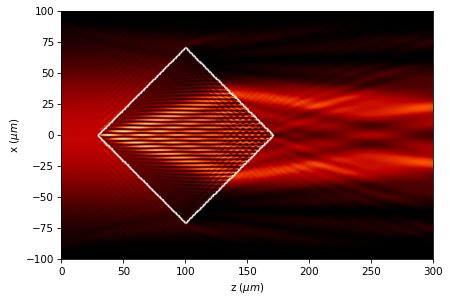

In [4]:
x0 = np.linspace(-100*um, 100*um, 512)
z0 = np.linspace(0*um, 300*um, 512)
wavelength = 5*um
u0 = Scalar_source_X(x=x0, wavelength=wavelength)
u0.gauss_beam(A=1, x0=0*um, z0=0*um, w0=75*um, theta=0*degrees)
u0.draw(
    kind='field',
    filename='usage4.png',
)

u1 = Scalar_mask_XZ(x=x0, z=z0, wavelength=wavelength)
u1.incident_field(u0)
u1.square(r0=(0*um, 100*um),
  size=(100*um, 100*um),
  angle=45*degrees,
  refractive_index=2)

u1.draw_refractive_index(
    filename='usage5.png', 
    scale='scaled',
)
u1.WPM(verbose=False)
u1.draw(
    logarithm=True, 
    normalize='maximum', 
    draw_borders=True, 
    filename='usage6.png', 
    scale='scaled'
)

## XY Fields:

In [5]:
from diffractio import um, nm, mm, np, degrees
from diffractio.scalar_sources_XY import Scalar_source_XY
from diffractio.scalar_fields_XY import Scalar_field_XY
from diffractio.scalar_masks_XY import Scalar_mask_XY

(<Figure size 480x360 with 1 Axes>,
 <Axes: xlabel='$x  (\\mu m)$', ylabel='$y  (\\mu m)$'>,
 <matplotlib.image.AxesImage at 0x12a95b2d0>)

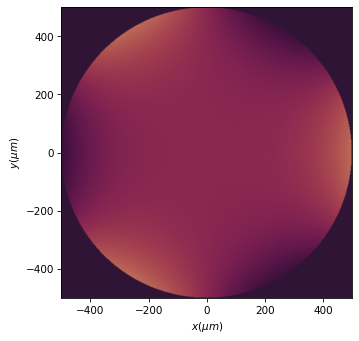

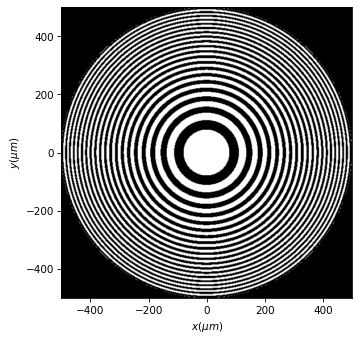

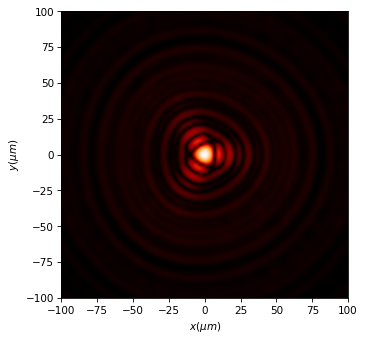

In [6]:
length = 1000*um
x0 = np.linspace(-length/2, length/2, 512)
y0 = np.linspace(-length/2, length/2, 512)
wavelength = 0.6238*um

focus=10*mm


u0 = Scalar_source_XY(x=x0, y=y0, wavelength=wavelength)

u0.zernike_beam(
    A=1,
    r0=(0*um, 0*um),
    radius=length/2,
    n=[0, 4,], 
    m=[0, 3,], 
    c_nm=[1, 0.25,]
)
u0.draw(kind='phase', filename='usage7.png')

t0 = Scalar_mask_XY(x=x0, y=y0, wavelength=wavelength)
t0.fresnel_lens(
  r0=(0*um, 0*um),
  radius=(500*um, 500*um),
  focal=(focus,focus),
  angle=0*degrees,
  kind='amplitude',
  phase=np.pi)
t0.draw(filename='usage8.png')

u1 = u0 * t0
u2 = u1.RS(z=focus, new_field=True)
u2.cut_resample(
  x_limits=(-100*um, 100*um),
  y_limits=(-100*um, 100*um),
  num_points=[1024, 1024],
  new_field=False)
u2.draw(kind='intensity', logarithm=True, filename='usage9.png')

## XYZ fields:

In [7]:
from diffractio import degrees, eps, mm, no_date, np, um
from diffractio.scalar_fields_XYZ import Scalar_field_XYZ
from diffractio.scalar_masks_XY import Scalar_mask_XY
from diffractio.scalar_masks_XYZ import Scalar_mask_XYZ
from diffractio.scalar_sources_XY import Scalar_source_XY

time in RS= 0.8097071647644043. num proc= 1


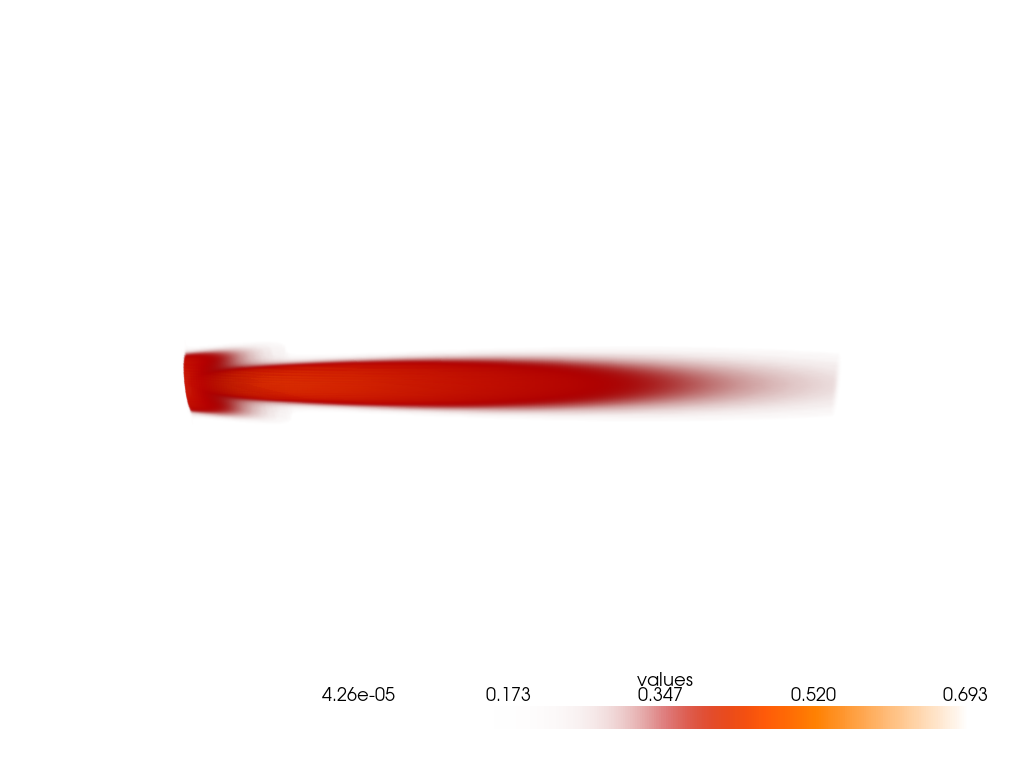

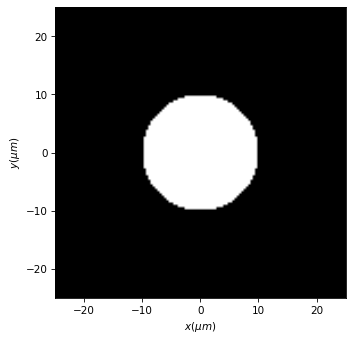

In [8]:
x0 = np.linspace(-25*um, 25*um, 128)
y0 = np.linspace(-25*um, 25*um, 128)
z0 = np.linspace(100*um, 500*um, 256)
wavelength = .6328*um

t1 = Scalar_mask_XY(x=x0, y=y0, wavelength=wavelength)
t1.circle(
    r0=(0*um, 0*um), radius=(10*um, 10*um), angle=0*degrees)
t1.draw(filename='usage10.png')

uxyz = Scalar_mask_XYZ(x=x0, y=y0, z=z0, wavelength=wavelength)
uxyz.incident_field(u0=t1)

uxyz.RS(verbose=True, num_processors=1)

uxyz.draw_XYZ(y0=0*mm, logarithm=True, normalize='maximum',filename='xyz_RS.png')
